# Drone Control via STREL — 8×8 Grid, 1 Base, 2 Drones

Same policy-gradient training as `training.ipynb`, but on a more complex scenario:
- **8×8** grid (vs 6×6)
- **2 drones** (vs 1)
- **1 charging station**

Larger state/action space → longer horizon, more iterations, slightly larger batch.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

from training.trainer import train_policy_gradient

## Hyperparameters

In [2]:
# Scenario
grid_side = 6   # 6x6 grid
n_bases   = 1
n_drones  = 2   # two drones
n_feat    = 6

# Training loop
T_total         = 70    # slightly longer horizon for larger grid
n_iterations    = 1000
batch_size      = 64
mini_batch_size = 16

# Policy architecture
policy_type   = 'mlp'   # 'mlp' | 'attention'
policy_hidden = 128     # wider network for larger obs

# Optimizer
lr               = 3e-4
grad_clip        = 1.0
action_reg_weight = 1e-2

# Manual step LR schedule
lr_schedule = {
    0:    3e-4,
    700:  5e-5,
    1200: 1e-5,
}

# Truncated BPTT
bptt_k = 10

# Asymmetric state drift penalty
drift_weight = 5.0

# Smooth STL annealing
smooth_beta_start        = 1.0
smooth_beta_end          = 100.0
smooth_beta_anneal_iters = 400

# Exploration noise
exploration_std          = 0.01
use_exploration_annealing = True
exploration_std_start    = 0.2
exploration_std_end      = 0.001
exploration_anneal_iters = 600

# Initial drone position: sampled uniformly from [init_pos_min, init_pos_max]
init_pos_min = 1.0
init_pos_max = 8.0

# Resume / checkpoint
use_resume_checkpoint      = False
resume_checkpoint_path     = 'policy_checkpoint_2.pt'
save_checkpoint_path       = 'policy_checkpoint_2.pt'
save_best_checkpoint_path  = 'policy_best_2.pt'

device = 'auto'  # 'auto', 'cpu', 'cuda'

## Pretrained Policy (optional)

Set `load_pretrained = True` to skip training and load a saved policy instead.

In [3]:
from policy.attention_policy import DroneAttentionPolicy
from policy.mlp_policy import DroneMLPPolicy

load_pretrained = False
pretrained_path = 'policy_pretrained_2.pt'

if load_pretrained:
    _dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    if policy_type == 'mlp':
        policy = DroneMLPPolicy(
            n_drones=n_drones,
            n_bases=n_bases,
            n_feat=n_feat,
            hidden=policy_hidden,
            out_channels=2,
            action_scale=2.0,
        ).to(_dev)
    elif policy_type == 'attention':
        policy = DroneAttentionPolicy(
            n_feat=n_feat,
            action_scale=2.0,
            d=16,
            n_latent=4,
            n_heads=2,
        ).to(_dev)
    else:
        raise ValueError("policy_type must be one of: 'mlp', 'attention'.")

    print(f'Policy parameters: {sum(p.numel() for p in policy.parameters()):,}')
    policy.load_state_dict(torch.load(pretrained_path, map_location=_dev, weights_only=True))
    policy.eval()
    history = None
    print(f"Loaded pretrained {policy_type} policy from '{pretrained_path}'")
else:
    print('load_pretrained=False — will train from scratch in the next cell.')

load_pretrained=False — will train from scratch in the next cell.


## Training

In [4]:
checkpoint_path = resume_checkpoint_path if use_resume_checkpoint else None

anneal_start = exploration_std_start if use_exploration_annealing else None
anneal_end   = exploration_std_end   if use_exploration_annealing else None
anneal_iters = exploration_anneal_iters if use_exploration_annealing else None

policy, history = train_policy_gradient(
    grid_side=grid_side,
    n_bases=n_bases,
    n_drones=n_drones,
    n_feat=n_feat,
    T_total=T_total,
    n_iterations=n_iterations,
    batch_size=batch_size,
    mini_batch_size=mini_batch_size,
    action_clip=2.0,
    policy_type=policy_type,
    policy_hidden=policy_hidden,
    lr=lr,
    lr_schedule=lr_schedule,
    grad_clip=grad_clip,
    action_reg_weight=action_reg_weight,
    bptt_k=bptt_k,
    drift_weight=drift_weight,
    smooth_beta_start=smooth_beta_start,
    smooth_beta_end=smooth_beta_end,
    smooth_beta_anneal_iters=smooth_beta_anneal_iters,
    exploration_std=exploration_std,
    exploration_std_start=anneal_start,
    exploration_std_end=anneal_end,
    exploration_anneal_iters=anneal_iters,
    init_pos_min=init_pos_min,
    init_pos_max=init_pos_max,
    checkpoint_path=checkpoint_path,
    save_checkpoint_path=save_checkpoint_path,
    save_best_checkpoint_path=save_best_checkpoint_path,
    device=device,
    show_progress=True,
    return_history=True,
)

stats = pd.DataFrame(history['stats'])

Policy: mlp | params: 19,076
LR schedule: [(0, 0.0003), (700, 5e-05), (1200, 1e-05)]
Smooth STL: beta 1.0 → 100.0 over 400 iters


Policy Gradient Training:   0%|          | 0/1000 [00:00<?, ?iter/s]

## Training Curves

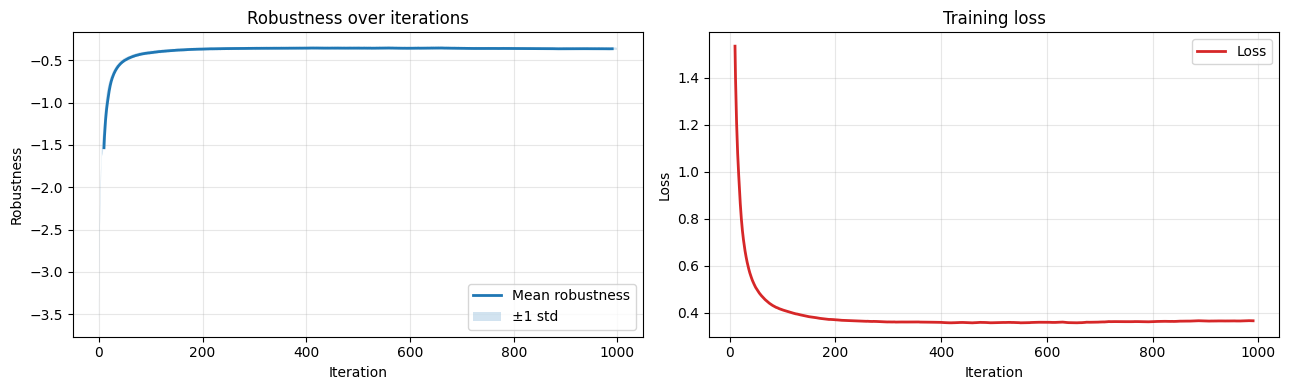

In [5]:
if history is not None:
    stats = pd.DataFrame(history['stats'])
    iters = np.arange(len(stats['mean']))

    fig, ax = plt.subplots(1, 2, figsize=(13, 4))

    ax[0].plot(iters, stats['mean'].rolling(window=20, center=True).mean(), label='Mean robustness', lw=2)
    ax[0].fill_between(
        iters,
        np.array(stats['mean']) - np.array(stats['std']),
        np.array(stats['mean']) + np.array(stats['std']),
        alpha=0.2, label='±1 std',
    )
    ax[0].set_title('Robustness over iterations')
    ax[0].set_xlabel('Iteration')
    ax[0].set_ylabel('Robustness')
    ax[0].grid(alpha=0.3)
    ax[0].legend()

    ax[1].plot(iters, stats['loss'].rolling(window=20, center=True).mean(), color='tab:red', lw=2, label='Loss')
    ax[1].set_title('Training loss')
    ax[1].set_xlabel('Iteration')
    ax[1].set_ylabel('Loss')
    ax[1].grid(alpha=0.3)
    ax[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print('No training history available (pretrained policy loaded).')

In [ ]:
# Save policy model (weights only, for inference)
torch.save(policy.state_dict(), 'policy_2.pt')
print("Policy model saved to 'policy_2.pt'")
print(f'Full training checkpoint path: {save_checkpoint_path}')

## Best vs Worst Episode

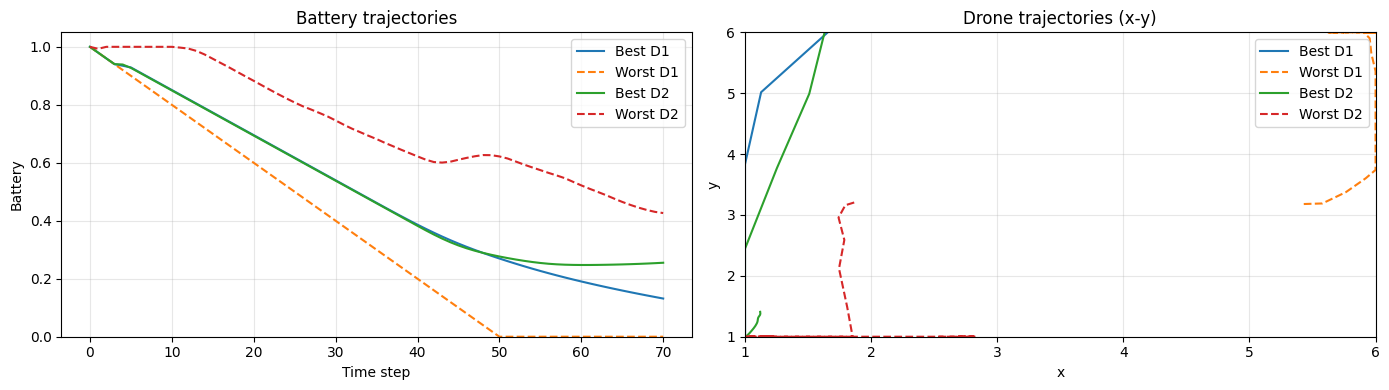

In [6]:
if history is not None:
    def traj_to_np(traj):
        return torch.stack(traj).permute(1, 2, 0).cpu().numpy()

    best_data  = traj_to_np(history['best']['trajectory'])
    worst_data = traj_to_np(history['worst']['trajectory'])
    n_drones_run = int(history['config'].get('n_drones', n_drones))
    drone_idxs   = list(range(best_data.shape[0] - n_drones_run, best_data.shape[0]))

    fig, ax = plt.subplots(1, 2, figsize=(14, 4))

    for i, idx in enumerate(drone_idxs):
        ax[0].plot(best_data[idx, 4, :],  label=f'Best D{i+1}')
        ax[0].plot(worst_data[idx, 4, :], linestyle='--', label=f'Worst D{i+1}')
    ax[0].set_title('Battery trajectories')
    ax[0].set_xlabel('Time step')
    ax[0].set_ylabel('Battery')
    ax[0].set_ylim(0, 1.05)
    ax[0].grid(alpha=0.3)
    ax[0].legend()

    for i, idx in enumerate(drone_idxs):
        ax[1].plot(best_data[idx, 0, :],  best_data[idx, 1, :],  label=f'Best D{i+1}')
        ax[1].plot(worst_data[idx, 0, :], worst_data[idx, 1, :], linestyle='--', label=f'Worst D{i+1}')
    ax[1].set_xlim(1, grid_side)
    ax[1].set_ylim(1, grid_side)
    ax[1].set_title('Drone trajectories (x-y)')
    ax[1].set_xlabel('x')
    ax[1].set_ylabel('y')
    ax[1].grid(alpha=0.3)
    ax[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print('No training history available (pretrained policy loaded).')